# Vantik — Prévisions : exploration et comparaison de modèles

**But de ce notebook** : validation académique (rapport de stage) de l'approche de prévision
retenue pour Vantik, *avant* son implémentation en production (TypeScript, `domain/services/`).

Ce notebook n'est **pas** une dépendance de l'application — il vit hors de `src/`, sert
uniquement à explorer les données réelles d'une entreprise et à comparer plusieurs modèles
de prévision de séries temporelles :

1. Exploration des données historiques (ventes, achats, charges, marge, demande par produit).
2. Implémentation de trois modèles : **Régression linéaire**, **Holt** (lissage exponentiel
   double, avec tendance), **Holt-Winters** (avec composante saisonnière).
3. Validation par **rolling-origin backtesting** (entraînement glissant, pas un simple
   split train/test — plus fiable sur peu de données).
4. Comparaison des modèles avec **MAE, RMSE et MAPE/sMAPE**.
5. Visualisation réel vs prédit, et identification du meilleur modèle par série.

Les données proviennent de la base Postgres réelle de l'application (entreprise de test
« forsa », 25 mois d'historique, données propres — pas d'anomalies injectées volontairement,
pour que la comparaison de modèles soit lisible).

## 1. Imports et connexion à la base de données

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Le .env du projet Next.js contient DATABASE_URL — c'est la même base que l'application.
load_dotenv(Path("..") / ".env")
engine = create_engine(os.environ["DATABASE_URL"])
print("Connecté à :", engine.url.database)

Connecté à : vantik


In [2]:
# Entreprise de test utilisée pour ce notebook (voir ROADMAP.md).
ENTREPRISE_ID = "16f92815-3d8a-4ca4-b1f6-4141811682ae"
NOM_ENTREPRISE = "forsa" 

## 2. Chargement des données brutes

On charge les commandes (avec leurs lignes), les charges, et les produits — les mêmes
tables que celles lues par `poserQuestionAssistant.ts` côté application. Une copie CSV est
sauvegardée dans `data/` pour que ce notebook reste reproductible même sans accès direct
à la base (utile pour joindre les données au rapport de stage).

In [3]:
commandes_sql = """
    SELECT c.id, c."type", c.statut, c."dateCommande",
           lc."produitId", lc.quantite, lc."prixApplique"
    FROM commandes c
    JOIN lignes_commande lc ON lc."commandeId" = c.id
    WHERE c."entrepriseId" = %(entreprise_id)s
"""
lignes = pd.read_sql(commandes_sql, engine, params={"entreprise_id": ENTREPRISE_ID})
lignes["dateCommande"] = pd.to_datetime(lignes["dateCommande"])
lignes["montant"] = lignes["quantite"] * lignes["prixApplique"].astype(float)

charges_sql = """
    SELECT id, "type", montant, "dateEcheance", recurrente
    FROM charges
    WHERE "entrepriseId" = %(entreprise_id)s
"""
charges = pd.read_sql(charges_sql, engine, params={"entreprise_id": ENTREPRISE_ID})
charges["dateEcheance"] = pd.to_datetime(charges["dateEcheance"])
charges["montant"] = charges["montant"].astype(float)

produits_sql = """
    SELECT id, nom, "prixAchat", "prixVente", "quantiteStock", "seuilAlerte"
    FROM produits
    WHERE "entrepriseId" = %(entreprise_id)s
"""
produits = pd.read_sql(produits_sql, engine, params={"entreprise_id": ENTREPRISE_ID})

Path("data").mkdir(exist_ok=True)
lignes.to_csv("data/lignes_commande.csv", index=False)
charges.to_csv("data/charges.csv", index=False)
produits.to_csv("data/produits.csv", index=False)

print(f"{len(lignes)} lignes de commande, {len(charges)} charges, {len(produits)} produits")
lignes.head()

2073 lignes de commande, 257 charges, 14 produits


,id,type,statut,dateCommande,produitId,quantite,prixApplique,montant
0,d82b9428-4aca-4d98-8807-b11ecc66376a,ACHAT_FOURNISSEUR,RECUE,2024-08-04 18:53:00,b1d3e895-75e6-42ad-a3f8-6bd8b9d22be8,11,15.0,165.0
1,d82b9428-4aca-4d98-8807-b11ecc66376a,ACHAT_FOURNISSEUR,RECUE,2024-08-04 18:53:00,3d69487c-f6bf-4558-b7c5-86dfd5caedb4,11,4.0,44.0
2,b7e74f97-87a1-4657-86ec-561e28517ddd,ACHAT_FOURNISSEUR,RECUE,2024-08-08 12:24:00,1d4729fb-527d-4107-b1d8-d718e7f64323,21,18.0,378.0
3,4477dd7c-2e29-40dd-9ae9-6c1264760f9e,ACHAT_FOURNISSEUR,RECUE,2024-08-05 16:45:00,2f9f7915-0f2d-4aa0-98fa-fbff272def4e,9,6.0,54.0
4,4477dd7c-2e29-40dd-9ae9-6c1264760f9e,ACHAT_FOURNISSEUR,RECUE,2024-08-05 16:45:00,82c9b156-9e48-4772-b6a4-610f88eed060,10,6.0,60.0


## 3. Séries mensuelles agrégées

Ventes livrées (`VENTE_CLIENT` + `RECUE`), achats reçus (`ACHAT_FOURNISSEUR` + `RECUE`),
charges totales, et marge (ventes − charges), un point par mois calendaire — même logique
que `calculerTendanceMensuelle` côté application.

In [4]:
def mois(dt_series):
    return dt_series.dt.to_period("M").dt.to_timestamp()

ventes = lignes[(lignes["type"] == "VENTE_CLIENT") & (lignes["statut"] == "RECUE")].copy()
achats = lignes[(lignes["type"] == "ACHAT_FOURNISSEUR") & (lignes["statut"] == "RECUE")].copy()

ventes["mois"] = mois(ventes["dateCommande"])
achats["mois"] = mois(achats["dateCommande"])
charges["mois"] = mois(charges["dateEcheance"])

ventes_mensuelles = ventes.groupby("mois")["montant"].sum().rename("ventes")
achats_mensuels = achats.groupby("mois")["montant"].sum().rename("achats")
charges_mensuelles = charges.groupby("mois")["montant"].sum().rename("charges")

serie = pd.concat([ventes_mensuelles, achats_mensuels, charges_mensuelles], axis=1).fillna(0.0)
serie = serie.sort_index()
serie["marge"] = serie["ventes"] - serie["charges"]

# On retire le mois en cours s'il est partiel (moins de 25 jours de données) — fausserait
# la fin de la série pour le backtesting.
aujourdhui = pd.Timestamp.today()
if serie.index[-1].to_period("M") == aujourdhui.to_period("M") and aujourdhui.day < 25:
    serie = serie.iloc[:-1]

serie.to_csv("data/serie_mensuelle.csv")
serie

,ventes,achats,charges,marge
mois,,,,
2024-08-01,1379.5,1189.0,2922.0,-1542.5
2024-09-01,1806.4,1311.0,3038.0,-1231.6
2024-10-01,1515.9,1592.0,3307.0,-1791.1
2024-11-01,4560.7,1566.0,3328.0,1232.7
2024-12-01,3801.0,1239.0,3002.0,799.0
2025-01-01,2417.6,894.0,2659.0,-241.4
2025-02-01,1710.1,1698.0,3444.0,-1733.9
2025-03-01,2820.2,1489.0,3248.0,-427.8
2025-04-01,3457.8,1016.0,2730.0,727.8


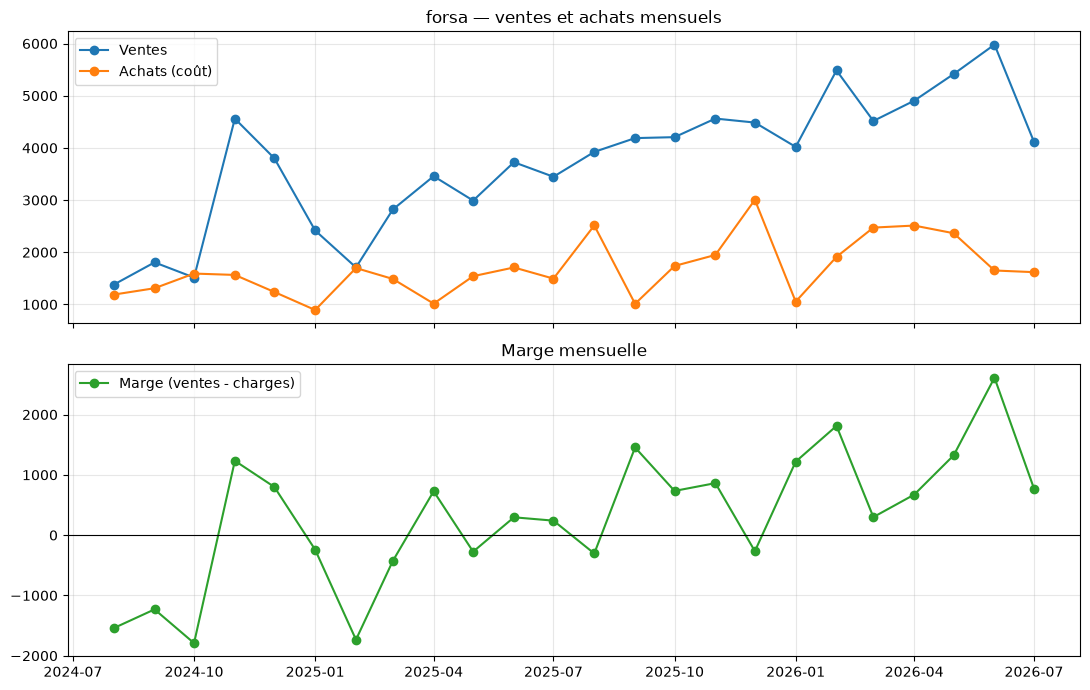

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(serie.index, serie["ventes"], marker="o", label="Ventes")
axes[0].plot(serie.index, serie["achats"], marker="o", label="Achats (coût)")
axes[0].set_title(f"{NOM_ENTREPRISE} — ventes et achats mensuels")
axes[0].legend()

axes[1].plot(serie.index, serie["marge"], marker="o", color="tab:green", label="Marge (ventes - charges)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Marge mensuelle")
axes[1].legend()

plt.tight_layout()
plt.savefig("data/fig_tendance_globale.png", dpi=150)
plt.show()

## 4. Demande par produit

On regarde la demande mensuelle (quantité vendue) pour quelques produits représentatifs :
un produit à forte saisonnalité hivernale, un à forte saisonnalité estivale, et les deux
meilleurs vendeurs toutes saisons confondues.

Volume total vendu par produit :
nom
T-shirt Basique           953
Jean Slim                 580
Sweat à Capuche           521
Chaussettes (Lot de 3)    250
Écharpe Hiver             246
Veste en Jean             239
Casquette                 181
Ceinture Cuir             180
Maillot de Bain           163
Name: quantite, dtype: int64


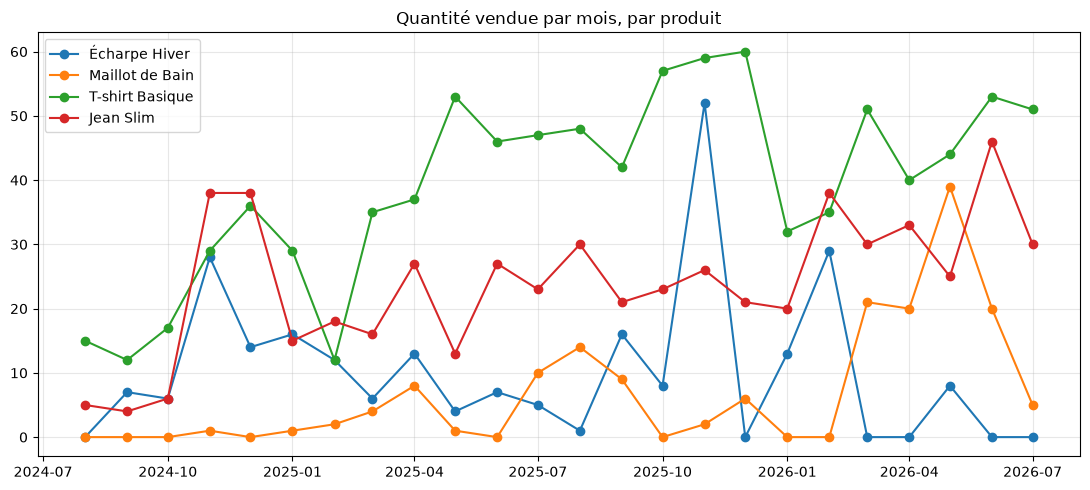

In [6]:
# Plusieurs lignes de produits partagent le même nom (variantes Taille/Couleur, ex. 4
# "T-shirt Basique" différents) — on agrège par nom, pas par produitId, pour avoir une
# seule série par nom de produit.
ventes_avec_nom = ventes.merge(produits[["id", "nom"]], left_on="produitId", right_on="id")
ventes_par_produit = ventes_avec_nom.groupby(["mois", "nom"])["quantite"].sum().reset_index()

total_par_produit = ventes_par_produit.groupby("nom")["quantite"].sum().sort_values(ascending=False)
print("Volume total vendu par produit :")
print(total_par_produit)

produits_a_tracer = ["Écharpe Hiver", "Maillot de Bain"] + list(total_par_produit.index[:2])
produits_a_tracer = list(dict.fromkeys(produits_a_tracer))  # dédoublonne en gardant l'ordre

fig, ax = plt.subplots(figsize=(11, 5))
for nom_produit in produits_a_tracer:
    sous_serie = ventes_par_produit[ventes_par_produit["nom"] == nom_produit].set_index("mois")["quantite"]
    sous_serie = sous_serie.reindex(serie.index, fill_value=0)
    ax.plot(sous_serie.index, sous_serie.values, marker="o", label=nom_produit)

ax.set_title("Quantité vendue par mois, par produit")
ax.legend()
plt.tight_layout()
plt.savefig("data/fig_demande_produits.png", dpi=150)
plt.show()

## 5. Modèles de prévision

Trois modèles, du plus simple au plus riche :

- **Régression linéaire** — une droite de tendance sur l'index temporel. Rapide, interprétable,
  aucune notion de saisonnalité.
- **Holt** (lissage exponentiel double) — capture le niveau *et* la tendance, s'adapte plus vite
  qu'une régression si la tendance change de pente en cours de route. Pas de saisonnalité.
- **Holt-Winters** (lissage exponentiel triple) — ajoute une composante saisonnière. Nécessite
  au moins deux cycles complets pour l'estimer correctement (nous exigeons ≥ 24 points).

In [7]:
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt


def prevoir_regression_lineaire(historique, horizon=1):
    x = np.arange(len(historique)).reshape(-1, 1)
    y = historique.values.astype(float)
    modele = LinearRegression().fit(x, y)
    x_futur = np.arange(len(historique), len(historique) + horizon).reshape(-1, 1)
    return modele.predict(x_futur)


def prevoir_holt(historique, horizon=1):
    modele = Holt(historique.values.astype(float), initialization_method="estimated").fit()
    return modele.forecast(horizon)


def prevoir_holt_winters(historique, horizon=1, periode_saisonniere=12):
    modele = ExponentialSmoothing(
        historique.values.astype(float),
        trend="add",
        seasonal="add",
        seasonal_periods=periode_saisonniere,
        initialization_method="estimated",
    ).fit()
    return modele.forecast(horizon)

## 6. Validation : rolling-origin backtesting

Avec seulement ~24 points mensuels, un simple split train/test (par ex. les 3 derniers mois en
test) donnerait une erreur mesurée sur 3 points seulement — bien trop bruité pour être fiable.

À la place : **rolling-origin backtesting**. On entraîne sur les mois `1..k`, on prédit le mois
`k+1`, on avance l'origine d'un mois, on recommence — jusqu'à épuiser la série. Chaque modèle
est ainsi testé sur autant de prévisions à 1 mois que l'historique le permet, ce qui donne une
mesure d'erreur bien plus stable.

Garde-fou : on n'entraîne jamais sur moins de 8 mois (`TAILLE_MIN_ENTRAINEMENT`) — sous ce seuil,
même le backtest n'est pas fiable, donc on ne compare pas de modèles du tout (voir ROADMAP.md).

In [8]:
TAILLE_MIN_ENTRAINEMENT = 8


def backtest_rolling_origin(serie_valeurs, fonction_prevision, taille_min_entrainement=TAILLE_MIN_ENTRAINEMENT, horizon=1):
    # NB : la fenetre d'entrainement grandit progressivement depuis taille_min_entrainement.
    # Un modele qui a besoin de plus de points (ex. Holt-Winters, >= 2 cycles saisonniers)
    # doit recevoir un taille_min_entrainement plus eleve, sinon ses premieres iterations
    # echoueront systematiquement (voir section 8).
    """serie_valeurs : pd.Series indexée par mois. Retourne un DataFrame origine/date_cible/reel/predit."""
    resultats = []
    n = len(serie_valeurs)
    for fin_entrainement in range(taille_min_entrainement, n - horizon + 1):
        entrainement = serie_valeurs.iloc[:fin_entrainement]
        reel = serie_valeurs.iloc[fin_entrainement:fin_entrainement + horizon]
        try:
            predit = fonction_prevision(entrainement, horizon=horizon)
        except Exception:
            continue
        for i, (date_cible, valeur_reelle) in enumerate(reel.items()):
            resultats.append({
                "origine": serie_valeurs.index[fin_entrainement - 1],
                "date_cible": date_cible,
                "reel": valeur_reelle,
                "predit": predit[i],
            })
    return pd.DataFrame(resultats)

## 7. Métriques d'erreur : MAE, RMSE, MAPE, sMAPE

In [1]:
def mae(reel, predit):
    reel, predit = np.asarray(reel, dtype=float), np.asarray(predit, dtype=float)
    return float(np.mean(np.abs(reel - predit)))


def rmse(reel, predit):
    reel, predit = np.asarray(reel, dtype=float), np.asarray(predit, dtype=float)
    return float(np.sqrt(np.mean((reel - predit) ** 2)))


def mape(reel, predit):
    reel, predit = np.asarray(reel, dtype=float), np.asarray(predit, dtype=float)
    masque = reel != 0
    if not masque.any():
        return np.nan
    return float(np.mean(np.abs((reel[masque] - predit[masque]) / reel[masque])) * 100)


def smape(reel, predit):
    """Symétrique : plus stable que le MAPE quand des mois ont un réel proche de 0."""
    reel, predit = np.asarray(reel, dtype=float), np.asarray(predit, dtype=float)
    denom = np.abs(reel) + np.abs(predit)
    masque = denom != 0
    if not masque.any():
        return np.nan
    return float(np.mean(2 * np.abs(reel[masque] - predit[masque]) / denom[masque]) * 100)


def calculer_metriques(bt):
    if bt.empty:
        return {"MAE": np.nan, "RMSE": np.nan, "MAPE (%)": np.nan, "sMAPE (%)": np.nan, "points_testes": 0}
    return {"MAE": mae(bt["reel"], bt["predit"]), "RMSE": rmse(bt["reel"], bt["predit"]),
            "MAPE (%)": mape(bt["reel"], bt["predit"]), "sMAPE (%)": smape(bt["reel"], bt["predit"]),
            "points_testes": len(bt)}

## 8. Comparaison sur le chiffre d'affaires global

On backteste chaque modèle sur la série mensuelle des ventes de l'entreprise, puis on compare.

**Point méthodologique important** : Holt-Winters a besoin d'au moins `2 * periode_saisonniere`
points (24 pour une saisonnalité annuelle) pour être *ajusté* — mais pour le *backtester*
correctement, il faut en plus plusieurs points *après* ce minimum, sinon il n'y a quasiment
aucune origine valide sur laquelle l'évaluer. Avec ~24-25 mois de données au total, ce
notebook exige au moins `MIN_POINTS_BACKTEST_HW` origines valides pour inclure Holt-Winters
dans la comparaison chiffrée ci-dessous — sinon il est exclu de la comparaison (mais un
ajustement unique, illustratif, est quand même montré plus bas).

In [10]:
PERIODE_SAISONNIERE = 12
MIN_POINTS_BACKTEST_HW = 4  # nombre minimal d'origines de backtest exigees pour Holt-Winters


def modeles_disponibles(longueur_serie, periode_saisonniere=PERIODE_SAISONNIERE, min_points_backtest_hw=MIN_POINTS_BACKTEST_HW):
    """Retourne {nom_modele: (fonction_prevision, taille_min_entrainement)}."""
    modeles = {
        "Régression linéaire": (prevoir_regression_lineaire, TAILLE_MIN_ENTRAINEMENT),
        "Holt": (prevoir_holt, TAILLE_MIN_ENTRAINEMENT),
    }
    minimum_hw = 2 * periode_saisonniere
    if longueur_serie - minimum_hw >= min_points_backtest_hw:
        fonction_hw = lambda h, horizon=1: prevoir_holt_winters(h, horizon=horizon, periode_saisonniere=periode_saisonniere)
        modeles["Holt-Winters"] = (fonction_hw, minimum_hw)
    return modeles


modeles = modeles_disponibles(len(serie))
print(f"Série de {len(serie)} mois. Modèles inclus dans le backtest :", list(modeles.keys()))
if "Holt-Winters" not in modeles:
    print(
        f"Holt-Winters exclu de la comparaison chiffrée : il faudrait au moins "
        f"{2 * PERIODE_SAISONNIERE + MIN_POINTS_BACKTEST_HW} mois d'historique pour le "
        f"backtester de façon fiable (contre {len(serie)} disponibles)."
    )

backtests_ventes = {
    nom: backtest_rolling_origin(serie["ventes"], fonction, taille_min_entrainement=taille_min)
    for nom, (fonction, taille_min) in modeles.items()
}
comparaison_ventes = pd.DataFrame({nom: calculer_metriques(bt) for nom, bt in backtests_ventes.items()}).T
comparaison_ventes.sort_values("RMSE")

Série de 24 mois. Modèles inclus dans le backtest : ['Régression linéaire', 'Holt']
Holt-Winters exclu de la comparaison chiffrée : il faudrait au moins 28 mois d'historique pour le backtester de façon fiable (contre 24 disponibles).


,MAE,RMSE,MAPE (%),sMAPE (%),points_testes
Holt,408.138607,541.413618,9.593678,9.222343,16.0
Régression linéaire,408.139369,541.415303,9.593681,9.222344,16.0


In [11]:
# Holt-Winters : ajustement unique sur toute la série, à titre illustratif seulement —
# non validé par backtesting si la série est trop courte (voir avertissement ci-dessus).
if "Holt-Winters" not in modeles:
    previsions_hw_illustratives = prevoir_holt_winters(serie["ventes"], horizon=3, periode_saisonniere=PERIODE_SAISONNIERE)
    print("Prévision Holt-Winters (illustrative, non backtestée) pour les 3 prochains mois :")
    print(np.round(previsions_hw_illustratives, 2))

Prévision Holt-Winters (illustrative, non backtestée) pour les 3 prochains mois :
[5422.8  5768.39 5632.26]


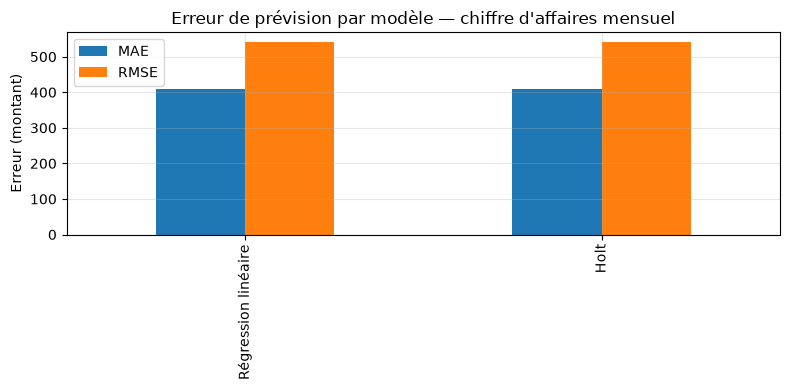

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
comparaison_ventes[["MAE", "RMSE"]].plot.bar(ax=ax)
ax.set_title("Erreur de prévision par modèle — chiffre d'affaires mensuel")
ax.set_ylabel("Erreur (montant)")
plt.tight_layout()
plt.savefig("data/fig_comparaison_modeles.png", dpi=150)
plt.show()

Meilleur modèle pour le chiffre d'affaires : Holt


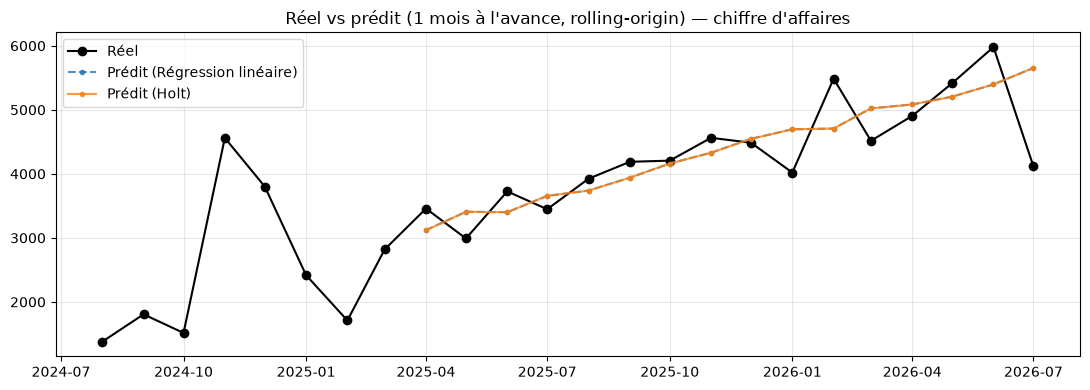

In [13]:
meilleur_modele_ventes = comparaison_ventes["RMSE"].idxmin()
print("Meilleur modèle pour le chiffre d'affaires :", meilleur_modele_ventes)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(serie.index, serie["ventes"], marker="o", label="Réel", color="black")
for nom, bt in backtests_ventes.items():
    style = "-" if nom == meilleur_modele_ventes else "--"
    ax.plot(bt["date_cible"], bt["predit"], style, marker=".", label=f"Prédit ({nom})", alpha=0.8)
ax.set_title("Réel vs prédit (1 mois à l'avance, rolling-origin) — chiffre d'affaires")
ax.legend()
plt.tight_layout()
plt.savefig("data/fig_reel_vs_predit_ventes.png", dpi=150)
plt.show()

## 9. Comparaison par produit

Même méthodologie, appliquée à la demande mensuelle (quantité vendue) de chaque produit
individuellement — le modèle gagnant peut différer d'un produit à l'autre (ex. un produit
saisonnier peut favoriser Holt-Winters, un produit à demande stable favorise la régression).

In [14]:
resultats_par_produit = []

for nom_produit in total_par_produit.index:
    sous_serie = ventes_par_produit[ventes_par_produit["nom"] == nom_produit].set_index("mois")["quantite"]
    sous_serie = sous_serie.reindex(serie.index, fill_value=0).astype(float)

    modeles_produit = modeles_disponibles(len(sous_serie))
    meilleure_ligne = None
    for nom_modele, (fonction, taille_min) in modeles_produit.items():
        bt = backtest_rolling_origin(sous_serie, fonction, taille_min_entrainement=taille_min)
        if bt.empty:
            continue
        metriques = calculer_metriques(bt)
        if meilleure_ligne is None or metriques["RMSE"] < meilleure_ligne["RMSE"]:
            meilleure_ligne = {"produit": nom_produit, "modèle_gagnant": nom_modele, **metriques}

    if meilleure_ligne:
        resultats_par_produit.append(meilleure_ligne)

resume_produits = pd.DataFrame(resultats_par_produit).set_index("produit")
resume_produits.to_csv("data/resume_meilleur_modele_par_produit.csv")
resume_produits

,modèle_gagnant,MAE,RMSE,MAPE (%),sMAPE (%),points_testes
produit,,,,,,
T-shirt Basique,Régression linéaire,8.901678,12.592077,22.303789,18.554992,16
Jean Slim,Régression linéaire,5.949252,7.511655,25.636453,21.968615,16
Sweat à Capuche,Holt,5.681141,7.411370,25.575626,23.970051,16
Chaussettes (Lot de 3),Régression linéaire,4.904928,6.606762,57.175188,45.924048,16
Écharpe Hiver,Régression linéaire,11.319798,15.140345,135.781288,111.120990,16
Veste en Jean,Régression linéaire,5.856401,7.070825,54.988362,69.251840,16
Casquette,Régression linéaire,5.340164,6.072129,71.397826,93.908560,16
Ceinture Cuir,Régression linéaire,6.275197,6.908819,113.836212,84.631802,16
Maillot de Bain,Régression linéaire,8.189182,10.445174,122.466792,111.669261,16


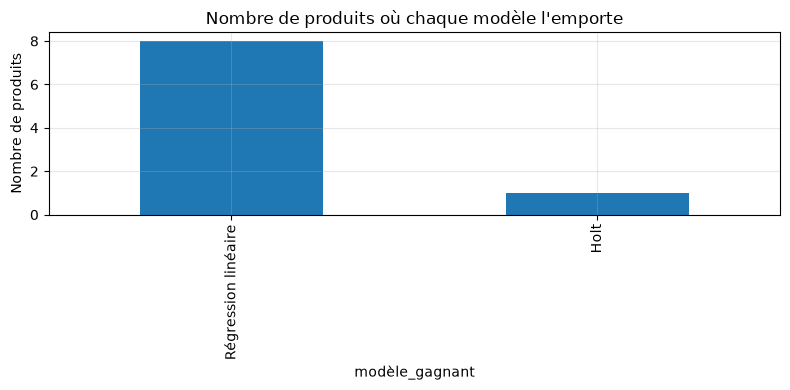

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
resume_produits["modèle_gagnant"].value_counts().plot.bar(ax=ax, color="tab:blue")
ax.set_title("Nombre de produits où chaque modèle l'emporte")
ax.set_ylabel("Nombre de produits")
plt.tight_layout()
plt.savefig("data/fig_modele_gagnant_par_produit.png", dpi=150)
plt.show()

## 10. Conclusion

- Le modèle gagnant sur le chiffre d'affaires global sert de référence pour la prévision
  « revenu global » de l'application.
- Le tableau par produit (section 9) montre que le meilleur modèle peut varier — c'est
  attendu, et c'est justement pourquoi la comparaison est refaite par entreprise (et par
  série) plutôt que fixée une fois pour toutes dans le code.
- Pour la marge (risque de perte), l'approche retenue est de projeter séparément les ventes
  et les charges avec le même modèle gagnant, puis de soustraire les deux projections —
  voir ROADMAP.md, section Intelligence artificielle.
- Cette méthodologie (régression / Holt / Holt-Winters, backtesting rolling-origin,
  MAE/RMSE/MAPE/sMAPE) est celle qui sera reproduite en TypeScript pur dans
  `domain/services/` pour la production — ce notebook ne sert qu'à la valider et à produire
  les graphes et chiffres de ce rapport de stage.